<h2 style="color:#2E86C1; text-align:center;">
Analysis of Security Inspection Performance and Risk Trends Across Healthcare Facilities - Exploratory Data Analysis (EDA)
</h2>

### Objective
The objective of this phase is to perform a comprehensive Exploratory Data Analysis (EDA) on the cleaned Security Inspection dataset to uncover meaningful operational and performance insights. This analysis aims to understand inspection trends, compliance behavior, risk patterns, and the impact of staffing on inspection outcomes.
This phase includes:

**Univariate Analysis**
To examine the distribution and characteristics of individual variables such as Inspection Score, Non-Compliance Count, Compliance Rate, and Staff on Duty. This helps identify patterns, variability, skewness, and potential outliers in the dataset.

**Bivariate Analysis**
To explore relationships between two variables, such as Inspection Score vs Non-Compliance Count and Region vs Performance Category. This helps understand how one factor influences or relates to another.

**Multivariate Analysis**
To analyze interactions among multiple variables simultaneously, such as Department, Risk Category, and Inspection Score. This provides deeper insights into operational dynamics and performance variations across different dimensions.

**Correlation Analysis**
To measure the strength and direction of relationships among numerical variables, including Inspection Score, Compliance Rate, Non-Compliance Count, and Staff on Duty. This helps identify key drivers of performance and operational efficiency.

### Import Libraries & Load Cleaned Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

df = pd.read_excel('Cleaned_Security_Inspection_Data.xlsx')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (16400, 22)


,Facility_ID,Facility_Name,Region,Department,Inspection_Type,Risk_Category,Inspection_Date,Inspector_ID,Guard_ID,Non_Compliance_Count,...,Inspection_Score,Uniform_Grooming_Score,Knowledge_Check_Score,Corrective_Action_Required,Follow_Up_Status,Remarks,Year,Month,Performance_Category,Compliance_Rate
0,1025,Medical Center,South,Admin,Spot Inspection,Medium,2025-08-23,301,5380,3,...,75.0,79,68,Yes,Closed,Guard briefed,2025,8,Good,70
1,1067,Medical Center,East,Radiology,Scheduled Audit,High,2025-07-24,275,7818,1,...,79.0,85,74,No,Closed,Needs refresher training,2025,7,Good,90
2,1103,General Hospital,West,ICU,Scheduled Audit,Low,2024-04-19,273,5126,2,...,85.0,77,77,No,Open,All OK,2024,4,Excellent,80
3,1092,General Hospital,South,OPD,Re-Audit,Low,NaT,289,8892,5,...,93.0,58,84,No,In Progress,Excellent compliance,2024,6,Excellent,50
4,1142,Community Hospital,Central,ICU,Re-Audit,Low,2025-08-15,283,8410,0,...,83.0,100,70,No,Closed,Follow-up required,2025,8,Good,100


## Univariate Analysis

### 1. Histogram – Inspection Score

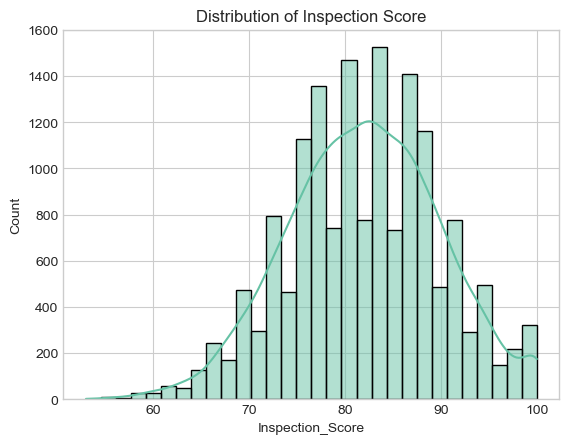

In [3]:
sns.histplot(df['Inspection_Score'], bins=30, kde=True)
plt.title('Distribution of Inspection Score')
plt.show()

**Interpretations: Shows overall performance spread and possible skewness**

### 2.Boxplot – Non-Compliance Count

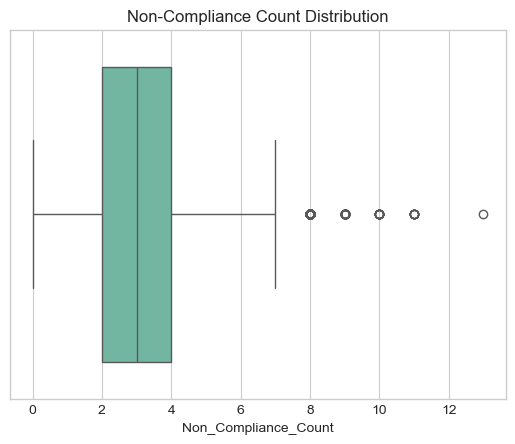

In [4]:
sns.boxplot(x=df['Non_Compliance_Count'])
plt.title('Non-Compliance Count Distribution')
plt.show()

**Interpretations: Identifies extreme compliance violations**

## Bivariate Analysis

### 3.Bar Chart – Average Inspection Score by Region

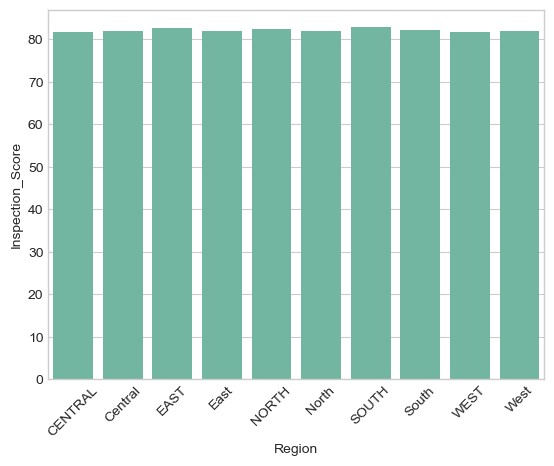

In [5]:
region_avg = df.groupby('Region')['Inspection_Score'].mean().reset_index()
sns.barplot(data=region_avg, x='Region', y='Inspection_Score')
plt.xticks(rotation=45)
plt.show()

🔑 Insight: Compares performance differences across regions.

### 4.Scatter Plot – Inspection Score vs Non-Compliance

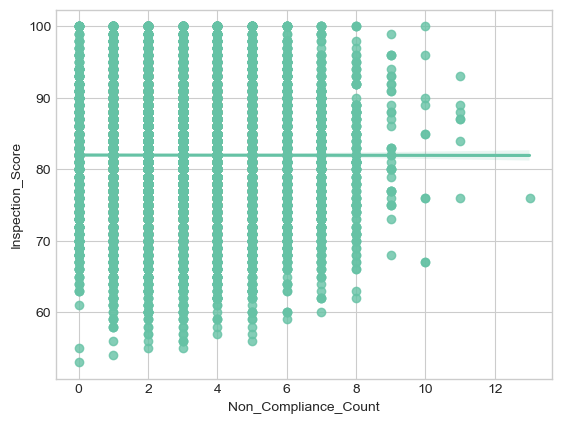

In [6]:
sns.regplot(data=df, x='Non_Compliance_Count', y='Inspection_Score')
plt.show()

**Interpretations:Shows negative relationship between violations and performance**

### 5.Count Plot – Risk Category Distribution

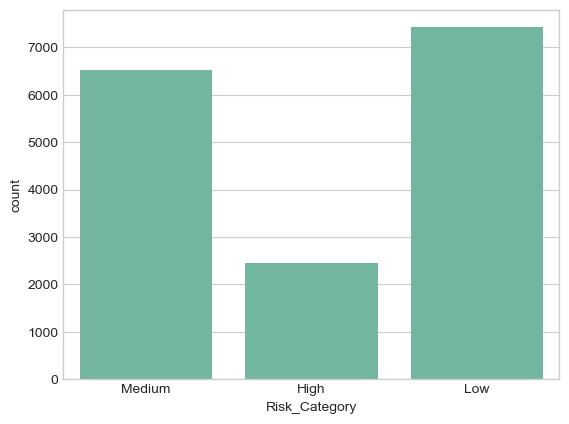

In [10]:
sns.countplot(data=df, x='Risk_Category')
plt.show()

**Interpretations: Identify dominant risk levels across facilities**

## Multivariate Analysis

### 6.Heatmap – Department vs Risk Category (Avg Score)

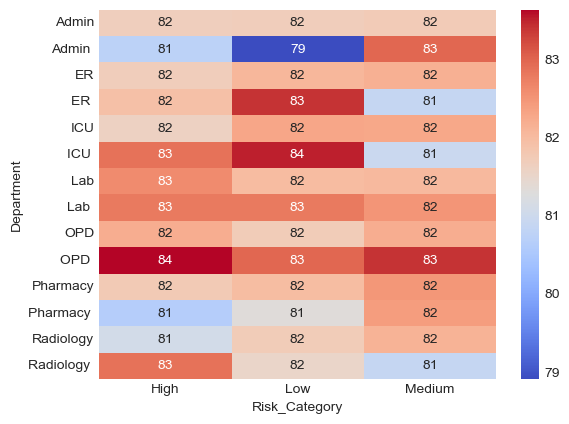

In [7]:
pivot = df.pivot_table(values='Inspection_Score', index='Department', columns='Risk_Category', aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.show()

**Interpretations: Identifies department performance variations under risk levels**

### 7. Grouped Bar – Region & Performance Category

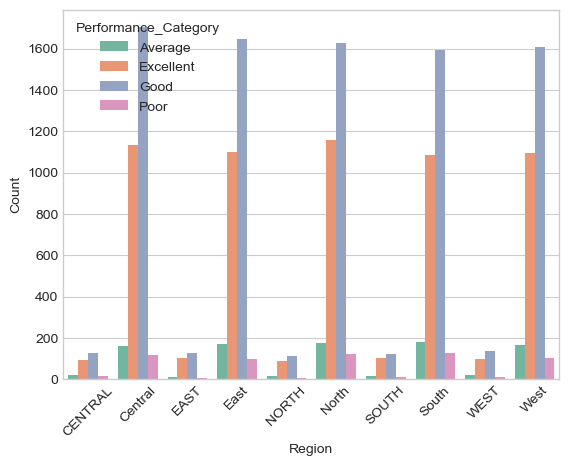

In [8]:
summary = df.groupby(['Region','Performance_Category']).size().reset_index(name='Count')
sns.barplot(data=summary, x='Region', y='Count', hue='Performance_Category')
plt.xticks(rotation=45)
plt.show()

**Interpretations: Shows performance distribution across regions**

### 8.Line Plot – Monthly Inspection Trend

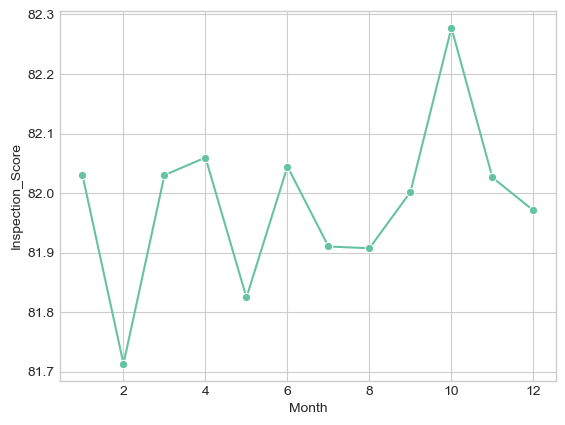

In [12]:
monthly = df.groupby('Month')['Inspection_Score'].mean().reset_index()
sns.lineplot(data=monthly, x='Month', y='Inspection_Score', marker='o')
plt.show()

**Interpretations: Identify seasonal or monthly performance trends**

## Correlation Analysis

### 9.Correlation Heatmap – Operational Metrics

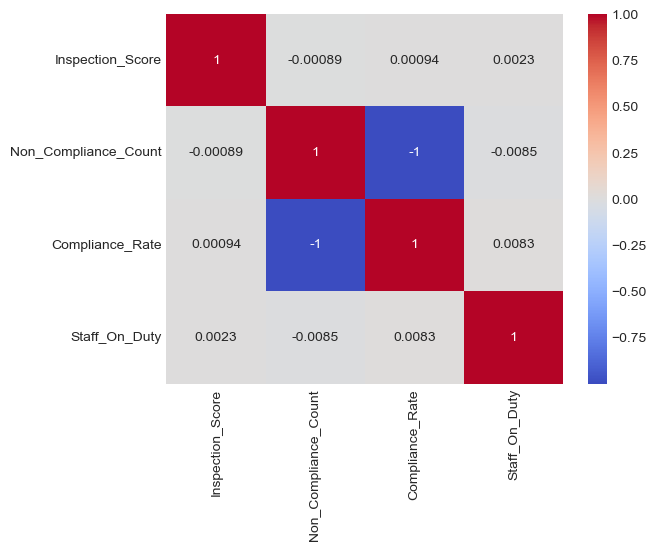

In [13]:
corr = df[['Inspection_Score','Non_Compliance_Count','Compliance_Rate','Staff_On_Duty']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

**Interpretations: Measure strength and direction of operational relationships**.

 ### 10.Regression Plot – Staff vs Inspection Score

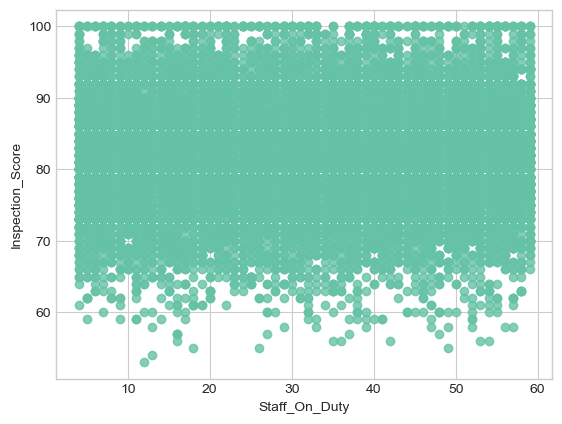

In [14]:
sns.regplot(data=df, x='Staff_On_Duty', y='Inspection_Score')
plt.show()

**Interpretations:Evaluate staffing impact on inspection performance**.